In [1]:
%pip install pandas matplotlib seaborn numpy scipy scikit-learn ipywidgets plotly nbformat

Note: you may need to restart the kernel to use updated packages.


# **Dados e Distribuições Amostrais**

Com a chegada do Big Data, um equívoco comum é achar que a amostragem perdeu relevância. Na prática, é o oposto: quanto mais dados existem, mais importante é amostrar bem, para trabalhar de forma eficiente e reduzir vieses. Mesmo em cenários de big data, modelos preditivos são treinados com amostras (bem coletadas), e testes como A/B testing também são feitos sobre amostras.

<img src="images_statistics/popxsample.png" width="600" style="display:block; margin:auto;">

A imagem ilustra os dois conceitos centrais desta seção: **População** (dados, à esquerda) e **Distribuição Amostral** (amostras, à direita).
- **População**: segue uma distribuição geralmente desconhecida.
- **Amostra**: obtida a partir da população via um processo de amostragem, com distribuição empírica conhecida, mas não necessariamente igual à da população.

Estatísticos tendem a focar na população, usando teoria e suposições sobre ela. Cientistas de dados, em geral, não precisam se preocupar com a natureza teórica da população, o foco deve estar no **processo de amostragem** e nos **dados amostrados**.

**Exceção**: quando o processo gerador dos dados pode ser modelado por uma distribuição conhecida. Exemplo clássico: eventos binários (comprar/não comprar, fraude/não fraude, clicar/não clicar) frequentemente seguem uma **distribuição binomial**, desde que respeitem suas duas premissas: *independência entre eventos e probabilidade de sucesso constante (nem todo evento binário é binomial)*. Nesses casos, ganhamos vantagem ao usar propriedades já conhecidas da distribuição, por exemplo, o valor esperado de um processo binomial é $np$ e a variância é $np(1-p)$.

## **Amostragem Aleatória e Viés de Amostra**

Uma **amostra** é um subconjunto de uma **população** (o conjunto de dados total, podendo ser teórico ou imaginário). Na hora de estimar ou modelar, a **qualidade** dos dados (completude, limpeza, representatividade) geralmente importa mais que a quantidade.

**Caso clássico, eleição EUA (Landon vs. Roosevelt, 1936)**: a revista *Literary Digest* enviou questionários para 10 milhões de assinantes e obteve 2,4 milhões de respostas, prevendo a vitória de Landon. Um pesquisador, com uma amostra de apenas 2.000 pessoas, previu corretamente a vitória de Roosevelt. O erro da revista veio do público que respondia: pessoas com renda suficiente para assinar a revista, um grupo sistematicamente diferente do eleitorado geral. Isso é um exemplo de **viés de amostragem não aleatório**: o erro não é aleatório porque tende sistematicamente em uma direção (aqui, para o público de maior renda).

### **Random Sampling (Amostragem Aleatória Simples)**
Cada elemento da população tem probabilidade igual de ser selecionado.
- **Com reposição**: o elemento sorteado volta para a população e pode ser sorteado novamente.
- **Sem reposição**: o elemento sorteado é removido e não pode ser sorteado de novo.

### **Self-Selection Sampling Bias**
Avaliações de restaurantes, hotéis, etc. tendem a ser enviesadas porque quem avalia **se autoseleciona**, geralmente pessoas com experiências extremas (muito boas ou muito ruins) ou com alguma ligação com o estabelecimento. Apesar de enviesadas para estimar a "verdade" (o quão bom é o restaurante), ainda são úteis para **comparação relativa** entre estabelecimentos, já que sofrem o mesmo tipo de viés.

### **Statistical Bias (Viés Estatístico)**
Erro estatístico é qualquer erro de medição ou amostragem. É importante distinguir:
- **Erro aleatório**: não tende a nenhuma direção específica.
- **Erro de viés**: tende sistematicamente para uma direção/padrão (ex: viés de gênero, quando um modelo favorece um gênero em situações onde não deveria).

Quando um resultado sugere viés, geralmente indica que variáveis importantes foram deixadas de fora ou que o modelo foi mal construído.

<img src="images_statistics/erro_vies.png" width="600" style="display:block; margin:auto;">

### **Stratified Sampling (Amostragem Estratificada)**
A chave de qualquer amostragem representativa é a **amostragem aleatória** bem definida, o que exige definir claramente a população de interesse (quem entra? dados históricos? devoluções?) e o processo de coleta.

**Problema da amostragem aleatória simples com grupos minoritários**: suponha uma população com P(negros) = 0.15, P(hispânicos) = 0.20, P(brancos) = 0.65. Uma amostra aleatória de 100 pessoas traria, no melhor caso, ~15 negros e ~20 hispânicos, tamanho pequeno demais para estimativas confiáveis sobre esses grupos.

**Solução**: dividir a população em **estratos** (grupos) e amostrar aleatoriamente dentro de cada um (ex: 100 de cada grupo). Isso garante amostras representativas por grupo, mas quebra a proporção real da população (deixa de ser 65%/15%/20% e passa a ser 33%/33%/33%).

Isso só importa quando você quer calcular uma métrica da **população inteira** (não de cada grupo isoladamente) a partir dessa amostra. Nesse caso, é preciso **reponderar** cada estrato pela sua proporção real na população antes de agregar os resultados, caso contrário, o cálculo trata os três grupos como se cada um representasse 33% da população, o que é falso.

Seja $N$ o tamanho total da população e $N_h$ o tamanho da população no estrato $h$, o peso de cada estrato é:

$$
W_h = \frac{N_h}{N}
$$

**Exemplo**: você quer estimar a renda média de toda a população. Coletou 100 pessoas de cada grupo (300 no total) e obteve as seguintes médias por estrato:

| Estrato | Peso real ($W_h$) | Renda média na amostra |
|---|---|---|
| Negros | 0.15 | R$ 3.000 |
| Hispânicos | 0.20 | R$ 3.500 |
| Brancos | 0.65 | R$ 5.000 |

Se você simplesmente tirar a média simples dos três valores (ignorando os pesos), obtém:
$$\bar{x}_{sem\ peso} = \frac{3000 + 3500 + 5000}{3} = 3833{,}33$$

Isso está errado, porque trata cada grupo como 33% da população, mas os brancos são 65%, não 33%. A estimativa correta pondera cada média pelo peso real do estrato:

$$\bar{x}_{com\ peso} = \sum_h W_h \cdot \bar{x}_h = (0{,}15 \times 3000) + (0{,}20 \times 3500) + (0{,}65 \times 5000) = R\$\ 4.400$$

Esse valor reflete corretamente a composição real da população, mesmo que a amostra coletada tenha tamanhos iguais por grupo.

### **Tamanho x Qualidade: quando o tamanho importa?**

Na era de big data, muitas vezes **amostras pequenas são preferíveis**: reduzem tempo e esforço, ajudam a reduzir viés, e facilitam a exploração dos dados (ex: rastrear a origem de outliers ou valores faltantes é inviável em big data, mas viável numa amostra).

**Quando big data realmente compensa**: em cenários de **cauda longa**, dados abundantes *e* esparsos. Exemplo: buscas do Google, onde queries raras precisam de muitos exemplos para o modelo aprender bem — exatamente o que big data oferece. Em resumo, big data é mais útil em problemas de cauda longa e alta esparsidade do que em problemas gerais de estimativa.

In [2]:
import pandas as pd

A_50 = ["A"] * 500
B_20 = ["B"] * 200
C_30 = ["C"] * 300
data = (A_50 + B_20 + C_30)
df = pd.DataFrame(data, columns=["Category"])

print("Contagem de cada categoria na população original:")
print(df["Category"].value_counts())

print("Amostragem sem reposição de 100 elementos:")
# amostragem sem reposição de 100 elementos
sample = df.sample(n=100, random_state=42, replace=False) # aqui, cada elemento só pode ser selecionado uma vez, depois de selecionar um elemento, ele é removido da população, então a próxima seleção é feita a partir dos elementos restantes
print(sample["Category"].value_counts())

print("Amostragem com reposição de 100 elementos:")
# amostragem com reposição de 100 elementos
sample_with_replacement = df.sample(n=100, random_state=42, replace=True) # aqui, cada elemento pode ser selecionado várias vezes, depois de selecionar um elemento, ele é colocado de volta na população, então a próxima seleção é feita a partir de todos os elementos, incluindo o que foi selecionado anteriormente
print(sample_with_replacement["Category"].value_counts())

sample_no_rep = df.sample(n=100, replace=False)
print("Duplicatas sem reposição:",
      sample_no_rep.index.duplicated().sum())

sample_rep = df.sample(n=100, replace=True)
print("Duplicatas com reposição:",
      sample_rep.index.duplicated().sum())

# amostragem estratificada
print("Amostragem estratificada:")

sample = (
    df
    .groupby("Category", group_keys=False)
    .sample(frac=0.1, random_state=42)
    .reset_index(drop=True)
)

print(sample["Category"].value_counts())


Contagem de cada categoria na população original:
Category
A    500
C    300
B    200
Name: count, dtype: int64
Amostragem sem reposição de 100 elementos:
Category
A    48
B    26
C    26
Name: count, dtype: int64
Amostragem com reposição de 100 elementos:
Category
A    56
C    27
B    17
Name: count, dtype: int64
Duplicatas sem reposição: 0
Duplicatas com reposição: 5
Amostragem estratificada:
Category
A    50
C    30
B    20
Name: count, dtype: int64


## **Viés de Seleção (Amostragem)**

Viés de seleção é a prática de selecionar observações de forma a levar a conclusões enganosas (propositalmente ou não). Idealmente, formulamos uma hipótese antes de testar os dados, mas, na prática, é comum fazer o inverso: procurar padrões nos dados já coletados e só depois criar uma hipótese que explique aquele padrão. O problema é que isso não distingue um efeito real de um artefato do acaso ("se você torturar os dados o suficiente, eles começam a falar").

### **Hipótese antes vs. depois dos resultados**

**Caso 1 — hipótese antes do teste**: uma pessoa afirma ser vidente e acerta 10 caras seguidas na sua frente.
$$P(\text{10 caras}) = (0.5)^{10} = \frac{1}{1024} \approx 0.001$$
Evento raro, se realmente aconteceu sem trapaça, é evidência forte a favor da hipótese (testada *antes* do resultado):
**Hipótese → Teste → Resultado**

**Caso 2 — hipótese depois do resultado**: 20.000 pessoas jogam a moeda 10 vezes cada, e uma delas acerta 10 caras seguidas.
$$P(\text{pelo menos um acerto}) = 1 - (1-p)^{20000} \approx 1 - e^{-20} \approx 0{,}9999998$$
Ou seja, é praticamente certo que **alguém** vá acertar, não porque essa pessoa é especial, mas porque houve milhares de tentativas. Apontar para quem acertou e chamá-la de vidente é viés de seleção: a hipótese surgiu **depois** de observar o resultado, ignorando todas as tentativas que falharam:
**Teste → Resultado → Hipótese**

O mesmo raciocínio se aplica quando um método é testado várias vezes e apenas o resultado mais bonito é publicado.

### **Vast Search Effect**
Quanto mais você procura por um padrão, maior a chance de encontrar um "falso positivo", um padrão que parece real, mas não vai se repetir no futuro.

### **Como prevenir**
- **Target Shuffling (teste de permutação)**: embaralhar os resultados e checar se o modelo ainda "acha" padrões, se sim, o método está enviesado.
- **Holdout Set**: separar dados que o modelo nunca viu; se o padrão encontrado no treino não aparece no holdout, era só sorte (overfitting).
- **Evitar viés de seleção na análise**: não escolher intervalos de tempo específicos que favoreçam a teoria, nem parar o experimento assim que o gráfico "parece bom".

### **Regressão à Média**
Fenômeno que descreve eventos raros/extremos: se algo muito bom ou muito ruim aconteceu hoje (longe da média), é improvável que se repita amanhã — a tendência é voltar para perto da média.

**Por quê**: a maioria dos eventos pode ser modelada como **fator fixo + fator aleatório (sorte)**. Um resultado extremo geralmente reflete um pico de sorte momentâneo, que tende a não se repetir.

**Exemplos**:
- **Kahneman — bronca vs. elogio**: instrutores de voo achavam que dar bronca melhorava o desempenho do aluno (e elogiar piorava), porque observavam melhora após bronca e piora após elogio. Na realidade, o desempenho ruim (ou ótimo) foi um desvio momentâneo que naturalmente regrediria à média — com ou sem bronca/elogio.
- **"Maldição" da capa da Sports Illustrated**: atletas que estampam a capa costumam ter desempenho pior logo depois — não por azar, mas porque estar na capa exige estar no auge (ponto extremo), e é estatisticamente difícil manter esse auge.


In [3]:
import numpy as np
np.random.seed(42)

# 1 experimento de jogar moeda 10 vezes e contar o número de caras
n_flips = 10
n_experiments = 1
results = np.random.binomial(n=n_flips, p=0.5, size=n_experiments) # aqui, n é o número de jogadas, p é a probabilidade de obter cara em cada jogada (0.5 para uma moeda justa), e size é o número de experimentos que queremos realizar (1 neste caso)

print("Número de caras em 10 jogadas:", results[0])

# 20000 experimentos de jogar moeda 10 vezes e contar o número de caras
n_experiments = 20000
results = np.random.binomial(n=n_flips, p=0.5, size=n_experiments)
print("Maximo de caras em 10 jogadas (20000 experimentos):", results.max())

# O retono do método binomial é um vetor em que cada posicao i é o número de sucessos (caras) em n jogadas no experimento i. Assim, results.max() retorna o número máximo de caras obtidas em 10 jogadas ao longo dos 20000 experimentos.

unique_counts = np.unique(results, return_counts=True)

print("Contagem de cada número de caras obtidas:")
for count, freq in zip(unique_counts[0], unique_counts[1]):
    print(f"{count} caras: {freq} vezes")

Número de caras em 10 jogadas: 4
Maximo de caras em 10 jogadas (20000 experimentos): 10
Contagem de cada número de caras obtidas:
0 caras: 24 vezes
1 caras: 183 vezes
2 caras: 894 vezes
3 caras: 2352 vezes
4 caras: 4073 vezes
5 caras: 4989 vezes
6 caras: 4047 vezes
7 caras: 2349 vezes
8 caras: 869 vezes
9 caras: 205 vezes
10 caras: 15 vezes


## **Distribuição de Soma/Médias Amostrais**

### **O que é**
Se amostrarmos a população **k** vezes, cada amostra de tamanho **n**, e calcularmos a média de cada uma, obtemos um conjunto de **k médias**. Conforme k cresce, essas médias formam a **distribuição de médias amostrais**.

### **Teorema Central do Limite (TCL)**

$$
\bar{X}_n \xrightarrow{d} \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right)
$$

A distribuição das médias de amostras aleatórias, tiradas de **qualquer população**, se aproxima de uma **Normal** (centrada na média populacional $\mu$) conforme o tamanho da amostra $n$ aumenta, **independentemente da distribuição original dos dados**. Na prática, $n \geq 30$ costuma ser suficiente para essa aproximação.

**A intuição**: cada elemento amostrado é uma variável aleatória independente, que pode "dar sorte" (valor alto) ou "azar" (valor baixo) em relação à média. Quando somamos/mediamos várias dessas variáveis, os desvios individuais (para cima e para baixo) tendem a se **cancelar entre si**, é raro que todos os elementos "puxem" na mesma direção ao mesmo tempo (Por exemplo em uma amostra de tamanho 20 precisariamos que tirar valores extremos que ja sao raros por si só 20 vezes seguidas o que torna mais raro ainda, é mais comum pergarmos um extremo para baixo e outro para cima e acabarem se cancelando). Esse cancelamento faz o resultado convergir para valores próximos do centro (a média populacional), e valores extremos ficam cada vez mais raros conforme somamos mais elementos, daí o formato de sino.

**Isso não é exclusivo da média**, o TCL vale para **qualquer soma (ou combinação linear) de variáveis aleatórias independentes**, desde que sejam somadas/agregadas em quantidade suficiente. A média é só a soma dividida por uma constante ($n$), então herda a mesma propriedade.

### **Erro Padrão (Standard Error)**
Mede a variabilidade da distribuição de médias amostrais, é o desvio padrão dessa distribuição:

$$
SE(\bar{X}) = \frac{\sigma}{\sqrt{n}}
$$

onde $\sigma$ é o desvio padrão da população e $n$ o tamanho da amostra.Como o desvio padrão populacional ($\sigma$) raramente está disponível (senão não precisaríamos de inferência estatística), na prática usa-se o **desvio padrão amostral** no lugar de $\sigma$.

O erro padrao quantifica em funcao do tamanho da amostra o quao confiavel é sua métrica calculada nessa amostra:
- Se o erro padrao é baixo entao variabilidade dos dados é baixa (Desvio padrao) ou a amostra é grande (Ou combinacoes)
- Se o erro padrao é alto entao variabilidade dos dados é alta (Desvio padrao) ou a amostra é muito pequena (Ou combinacoes)

Quanto maior $n$, menor o erro padrão, ou seja, menos incerteza temos de qualquer métrica tirada da amostra. No limite, com $n \to \infty$, a distribuição de médias amostrais converge para a média populacional com erro padrão zero, isso é a **Lei dos Grandes Números**.

### **Lei dos Grandes Números**

$$
P\left( \lim_{n \to \infty} \bar{X}_n = \mu \right) = 1
$$

Quanto maior a amostra, mais a média amostral se aproxima da média real da população.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, IntSlider

np.random.seed(42) # Para garantir que a população seja sempre a mesma

# Usamos uma Log-Normal para simular a assimetria clássica de salários
populacao_bruta = np.random.lognormal(mean=10.8, sigma=0.8, size=100000)

# Filtramos apenas rendas entre 10k e 200k, igual ao seu filtro do pandas
populacao_filtrada = populacao_bruta[(populacao_bruta >= 10000) & (populacao_bruta <= 200000)]

# Sorteamos 20.000 pessoas para ser o nosso "universo" fixo
populacao_renda = populacao_filtrada[:20000]
media_populacional = np.mean(populacao_renda)


def simular_tcl(n, k):
    # Coletar 'k' amostras de tamanho 'n' com reposição
    # E calcular a média de cada uma instantaneamente
    medias_amostrais = [np.mean(np.random.choice(populacao_renda, size=n, replace=True)) for _ in range(k)]
    
    media_das_medias = np.mean(medias_amostrais)
    erro_padrao = np.std(medias_amostrais, ddof=1)
    
    # Configurar o estilo do gráfico
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")
    
    # Plot 1: A População Original (Cinza e achatada no fundo)
    sns.kdeplot(populacao_renda, color='gray', alpha=0.3, fill=True, lw=0, label='População Original (Assimétrica)')
    
    # Plot 2: A Distribuição das Médias (Laranja/Azul mostrando o "sino")
    sns.kdeplot(medias_amostrais, color='darkorange', alpha=0.7, fill=True, lw=2, label=f'Médias Amostrais (n={n})')
    
    # Linhas de referência para as médias
    plt.axvline(media_populacional, color='black', linestyle='--', linewidth=2, alpha=0.8, 
                label=f'Média População: R$ {media_populacional:,.0f}')
    plt.axvline(media_das_medias, color='red', linestyle=':', linewidth=2, 
                label=f'Média das Amostras: R$ {media_das_medias:,.0f}')
    
    # Textos e formatações
    plt.title(f'Teorema Central do Limite em Ação\nErro Padrão (Largura do Sino): R$ {erro_padrao:,.2f}', fontsize=14)
    plt.xlabel('Renda Anual', fontsize=12)
    plt.ylabel('Densidade', fontsize=12)
    
    # Travar o eixo X para que o visual do "estreitamento" da curva seja nítido
    plt.xlim(10000, 150000) 
    
    # Ajustar legenda e remover bordas
    plt.legend(loc='upper right', frameon=True)
    sns.despine()
    
    plt.tight_layout()
    plt.show()

print("Deslize os controles abaixo para simular a extração das amostras:")
interact(simular_tcl, 
         n=IntSlider(min=2, max=200, step=1, value=30, description='Tam. Amostra (n):', 
                     style={'description_width': 'initial'}, layout={'width': '500px'}, continuous_update=False),
         k=IntSlider(min=100, max=3000, step=100, value=1000, description='Total Amostras (k):', 
                     style={'description_width': 'initial'}, layout={'width': '500px'}, continuous_update=False));

Deslize os controles abaixo para simular a extração das amostras:


interactive(children=(IntSlider(value=30, continuous_update=False, description='Tam. Amostra (n):', layout=Lay…

## **Intervalo de Confiança (IC)**

Uma amostra, por ser fruto de um processo aleatório, dificilmente representa a população com perfeição. Quando queremos estimar um valor/métrica da população a partir dela, não faz sentido apresentar só um número fixo, em vez disso, construímos um intervalo com X% de confiança de que o valor real da população está contido nele. Com esse intervalo, **queremos quantizar a incerteza da nossa estimativa**: em vez de fingir que sabemos o valor exato, admitimos uma faixa plausível e dizemos o quão confiantes estamos nela.

**100% de confiança não é útil**: equivaleria a dizer que o valor está entre $-\infty$ e $+\infty$ (ou que você amostrou a população inteira, sem erro nenhum).

### **O que "confiança" realmente significa**

Depois que a amostra já foi coletada, o intervalo de confiança está **fixo**, ou ele contém o valor real, ou não contém (não existe mais "probabilidade" nesse momento, já que não há mais aleatoriedade envolvida). É como um bilhete de loteria já comprado: ou você ganhou, ou não, não faz sentido falar em "95% de chance de ter ganhado" depois do sorteio. A aleatoriedade está **antes**, no processo de amostragem. Por isso a interpretação correta de "IC de 95%" é: *"se eu repetisse esse processo de amostragem muitas vezes, 95% das amostras coletadas gerariam um intervalo que contém o valor real da população"*, não "há 95% de chance do valor estar neste intervalo específico".

### **IC Paramétrico**

Usa o **TCL** a seu favor: como a distribuição de médias amostrais se aproxima de uma Normal centrada na média real ($\mu$) conforme $n$ cresce, sabemos que a maioria das médias amostrais cai perto do centro dessa Normal, e só ocasionalmente cai nas caudas (longe de $\mu$). O intervalo de confiança é a **janela** aberta para os dois lados da média amostral, larga o suficiente para capturar uma determinada porcentagem da área dessa distribuição Normal. Com 95% de confiança, essa janela cobre 95% da área central, só falharia em capturar $\mu$ se a média amostral obtida tivesse caído numa das caudas (evento raro, por construção).

$$
CI = \bar{x} \pm z_{\alpha/2}\left(\frac{s}{\sqrt{n}}\right)
$$

A margem de erro é construída em duas partes:
- **$z$ (ou $t$)**: quantos desvios padrão da média é preciso andar para os dois lados para cobrir $(100-\alpha)\%$ da distribuição
- **Erro padrão** ($s/\sqrt{n}$): a variabilidade da estimativa

O produto dos dois dá a distância (para cada lado) que define a largura do intervalo.

**t-Student**: criada em 1908 por um estatístico (William Gosset, da Guinness) que trabalhava com amostras pequenas e notou que o erro padrão estimado com poucos dados tende a ser subestimado, gerando intervalos de confiança irrealisticamente estreitos. A distribuição **t** corrige isso, tendo caudas mais "pesadas" que a Normal, como um "z mais cauteloso", que alarga o intervalo para compensar a incerteza extra de estimar $s$ com poucos dados. Conforme $n$ cresce, a t converge para a Normal (por isso $n \geq 30$ costuma dispensar a correção).

**Desvantagens:** exige que a distribuição amostral seja aproximadamente Normal (nao é verdade com n pequeno, ou métricas que nao envolvem uma soma/media), assume que o intervalo é simétrico (falso para distribuicoes amostrais assimetricas onde um lado do intervalo pode pegar mais) e que o erro padrão estimado está correto (oq é improvavel já que é uma amostra), e só **funciona quando existe uma fórmula fechada de erro padrão**, o que a média tem, mas mediana não têm.

### **IC Não Paramétrico**

"Não paramétrico" é **qualquer metodo que não assume uma forma distribucional específica (como a Normal do TCL) para construir o intervalo**. Dentro dessa categoria existem várias abordagens (baseadas em estatísticas de ordem, em testes de sinal, em ranks etc.), um exemplo é o bootstrap. O bootstrap usa *simulação*: trata a amostra coletada como se fosse a própria população, e gera novas amostras via reamostragem com reposição, recalculando a métrica de interesse em cada reamostragem. Isso constrói uma distribuição empírica (a distribuição bootstrap) da métrica, a partir da qual o intervalo de confiança pode ser extraído de varias formas.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from ipywidgets import interact, IntSlider, Dropdown

def simular_intervalos_confianca(n, nivel_confianca):
    # 1. Parâmetros reais da população (O "poste" invisível)
    media_real = 100
    desvio_padrao_real = 15
    num_amostras = 100

    # 2. Encontrar o Z-score adequado para o nível de confiança escolhido
    # stats.norm.ppf pega a % acumulada. (Ex: para 95%, deixa 2.5% em cada cauda, logo 0.975)
    z_score = stats.norm.ppf(1 - (1 - nivel_confianca) / 2)

    # 3. Gerar 100 amostras (linhas) de tamanho n (colunas)
    # Aqui a magia acontece: sorteamos dados de uma Normal verdadeira
    amostras = np.random.normal(loc=media_real, scale=desvio_padrao_real, size=(num_amostras, n))

    # 4. Calcular a média de cada amostra (nossas "flechas")
    medias_amostrais = np.mean(amostras, axis=1)

    # 5. Calcular o Erro Padrão e a Margem de Erro
    erro_padrao = desvio_padrao_real / np.sqrt(n)
    margem_erro = z_score * erro_padrao

    # 6. Limites do Intervalo de Confiança [Média - Erro, Média + Erro]
    limite_inferior = medias_amostrais - margem_erro
    limite_superior = medias_amostrais + margem_erro

    # ================= VISUALIZAÇÃO =================
    plt.figure(figsize=(10, 8))
    acertos = 0

    # plotar cada um dos 100 intervalos
    for i in range(num_amostras):
        # Avaliar se a média real caiu dentro do intervalo calculado
        conteve_media = limite_inferior[i] <= media_real <= limite_superior[i]

        if conteve_media:
            cor = '#2ecc71' # Verde (Acerto)
            acertos += 1
        else:
            cor = '#e74c3c' # Vermelho (Erro/Azar)

        # Desenhar a linha horizontal do intervalo
        plt.plot([limite_inferior[i], limite_superior[i]], [i, i], color=cor, alpha=0.8, linewidth=2)
        # Marcar a média da amostra no centro do intervalo
        plt.plot(medias_amostrais[i], i, 'o', color=cor, markersize=4)

    # Desenhar a linha vertical da Média Real
    plt.axvline(x=media_real, color='black', linestyle='--', linewidth=2, label='Média Real da População')

    # Ajustes estéticos do gráfico
    plt.title(f'Simulação: 100 Intervalos de Confiança ({nivel_confianca*100:.0f}%)\nAcertos: {acertos} | Erros: {100 - acertos}', fontsize=14)
    plt.xlabel('Valores', fontsize=12)
    plt.ylabel('Amostras Coletadas (1 a 100)', fontsize=12)
    plt.yticks([]) # Oculta os números do eixo Y para focar nas linhas
    plt.xlim(media_real - (3 * desvio_padrao_real), media_real + (3 * desvio_padrao_real)) # Fixar o eixo X para evitar pulos na animação
    plt.legend(loc='upper right')
    plt.grid(axis='x', linestyle=':', alpha=0.6)
    
    plt.show()

interact(
    simular_intervalos_confianca,
    n=IntSlider(min=5, max=100, step=5, value=30, description='Tamanho (n):'),
    nivel_confianca=Dropdown(options=[('90% (Z=1.64)', 0.90), ('95% (Z=1.96)', 0.95), ('99% (Z=2.57)', 0.99)], value=0.95, description='Confiança:')
);

interactive(children=(IntSlider(value=30, description='Tamanho (n):', min=5, step=5), Dropdown(description='Co…

## **Bootstrap**

Imagine que o processo de conseguir amostras seja extremamente caro ou até impossível no momento. Como estimaríamos a média populacional e o erro padrão sem poder amostrar mais da população (como o TCL exige)? O Bootstrap resolve isso. 

**O que é**: a forma mais fácil e efetiva de estimar a distribuição amostral de uma estatística usando apenas uma amostra original. Consiste em sortear amostras extras **com reposição** (reamostragem) a partir da própria amostra, recalculando a estatística de interesse em cada reamostragem.

**Premissas**:
- A amostra original precisa ter boa qualidade e representatividade da população. Se ela for viesada ou pequena demais, o Bootstrap apenas "multiplica" esse erro, ele não cria informação nova, apenas extrai a incerteza que já existe nos dados.
- Os valores precisam ser **independentes**, séries temporais não se aplicam diretamente.

### **Algoritmo**

Assumindo uma boa amostra original de tamanho *n*:

1. Sorteie um valor aleatório da amostra original e anote
2. Devolva o valor para a amostra original
3. Repita 1 e 2 até ter uma nova amostra de mesmo tamanho *n* (com repetição)
4. Calcule a estatística de interesse (ex: média) dessa nova amostra e anote
5. Repita os passos 1-4 por *k* vezes (o número de iterações do algoritmo)

Quanto maior o *k*, mais exatas as estimativas de erro padrão, média ou intervalo de confiança.

O resultado é um conjunto de estatísticas (uma distribuição) que pode ser usado para:
- Calcular o desvio padrão delas → **erro padrão**
- Criar um boxplot ou histograma
- Extrair um **intervalo de confiança**

### **Bootstrap com múltiplas variáveis**

Pode ser usado em pontos n-dimensionais (ex: features de um problema), onde **linhas inteiras** são amostradas como unidade, mantendo a relação entre as colunas em cada reamostragem.

<img src="images_statistics/bootstrap_multi.png" width="600" style="display:block; margin:auto;">

### **Bootstrap x Computadores**

É uma técnica computacionalmente cara, por isso demorou a ficar popular. Hoje é usada até para encontrar o tamanho ideal de amostra: se você fez um teste piloto com 20 dados e o erro padrão está alto, pode usar o Bootstrap para simular "e se eu tivesse 100 dados?" sem precisar coletar de fato.

### **Quando usar**

Pode ser usado com qualquer estatística, média, mediana, F1, NDCG etc. Não impõe forma paramétrica rígida; usa os próprios dados para aproximar a distribuição amostral, dispensando a fórmula fechada de erro padrão que métricas não-lineares não têm.

**Limitaçoes:** com amostras muito pequenas (< 20), o bootstrap tende a ser uma má escolha, há pouca variedade nos dados originais para simular de forma confiável a variabilidade da população. **A amostra é a única informação que o bootstrap tem sobre a população**, então qualquer característica extrema da população (assimetria, outliers, cauda pesada) que não esteja bem representada na amostra finita vira um ponto cego do método. Quanto menor a amostra, maior a chance de ela não representar bem essas características, e pior a cobertura do IC (mesmo com amostras suficientemente grandes, se as distribuicoes forem estranhas ainda pode ter um resultado com baxia combertura).



In [6]:
import numpy as np
import pandas as pd
from sklearn.utils import resample
import plotly.express as px

# ==========================================
# 1. GERAÇÃO DOS DADOS SINTÉTICOS
# ==========================================
np.random.seed(42)
# Simulando dados de renda com assimetria à direita usando uma distribuição log-normal
income = np.random.lognormal(mean=10.5, sigma=0.5, size=1000)

# ==========================================
# 2. APLICAÇÃO DO BOOTSTRAP (SKLEARN)
# ==========================================
results = []
n_iterations = 1000

for _ in range(n_iterations):
    # Gerando amostras com reposição do mesmo tamanho da amostra original
    sample = resample(income, replace=True, n_samples=len(income))
    results.append(sample.mean())

results_series = pd.Series(results)

# Extraindo as métricas principais
media_original = income.mean()
ic_inferior, ic_superior = np.percentile(results_series, [2.5, 97.5])

print("=== Métricas do Bootstrap ===")
print(f"Média original: {media_original:.2f}")
print(f"Média bootstrap: {results_series.mean():.2f}")
print(f"Desvio padrão bootstrap: {results_series.std():.2f}")
print(f"Intervalo de confiança (95%): [{ic_inferior:.2f}, {ic_superior:.2f}]\n")

# ==========================================
# 3. PLOT INTERATIVO (PLOTLY)
# ==========================================
fig = px.histogram(
    results_series, 
    nbins=50, 
    title="Distribuição das Médias de Bootstrap da Renda (Interativo)", 
    labels={'value': 'Média de Renda', 'count': 'Frequência'},
    color_discrete_sequence=['#2ab7ca']
)

# Adicionando a linha da Média Original
fig.add_vline(
    x=media_original, line_dash="solid", line_color="#fe4a90", 
    annotation_text=f"Média Original: {media_original:.0f}", 
    annotation_position="top left"
)

# Adicionando a linha do Limite Inferior do Intervalo de Confiança
fig.add_vline(
    x=ic_inferior, line_dash="dash", line_color="#011f4b", 
    annotation_text="IC 2.5%", annotation_position="bottom right"
)

# Adicionando a linha do Limite Superior do Intervalo de Confiança
fig.add_vline(
    x=ic_superior, line_dash="dash", line_color="#011f4b", 
    annotation_text="IC 97.5%", annotation_position="bottom right"
)

fig.update_layout(showlegend=False)
fig.show()

=== Métricas do Bootstrap ===
Média original: 41434.56
Média bootstrap: 41455.49
Desvio padrão bootstrap: 716.49
Intervalo de confiança (95%): [40013.60, 42887.67]



## Distribuição Normal

A distribuição normal não é chamada assim porque é comum e a maioria dos datasets a seguem, na prática, a maioria dos dados brutos tem cauda longa (assimétrica). Ela é famosa e útil porque **a distribuição amostral de várias estatísticas** (média, entre outras) tende a se aproximar dela conforme *n* cresce, isso é o Teorema Central do Limite (TCL) agindo, não uma propriedade natural dos dados brutos. Ainda assim, **assumir normalidade é o último recurso**: só quando você não tem dados suficientes (ou hardware) para rodar um bootstrap.

**Regra empírica (68-95-99.7)**: numa distribuição normal, ~68% dos dados estão a 1 desvio padrão da média, ~95% a 2 desvios padrão, e ~99,7% a 3 desvios padrão.

### **Normal padrão e Z-score**

$$
z = \frac{x - \bar{x}}{s}
$$

A normal padrão é a distribuição original convertida em **z-scores**, que representam o número de desvios padrão de distância da média (média 0, desvio padrão 1).

### **QQ-plots**

Gráfico usado para visualizar o quão próxima uma amostra está de uma distribuição de referência (normal, binomial etc.).

**Como funciona**:
- Eixo Y: valores da amostra, **ordenados** do menor para o maior
- Eixo X: quantis **esperados** pela distribuição de referência
- Uma linha diagonal (y = x) mostra como os pontos deveriam se comportar **se** os dados realmente seguissem a distribuição de referência

Exemplo: numa amostra de 100 valores, se o menor valor observado é 5, o ponto plotado é `(quantil(0.01) da normal, 5)`.

**Interpretação**:
- Ponto **abaixo** da linha → valor observado está abaixo do esperado pela distribuição de referência
- Ponto **acima** da linha → valor observado está acima do esperado
- Ponto **sobre** a linha → de acordo com a distribuição de referência
- Desvios sistemáticos nas pontas indicam caudas mais pesadas ou mais leves que a referência 

Também é possível comparar duas amostras entre si (uma no eixo X, outra no eixo Y) em vez de comparar com uma distribuição teórica.

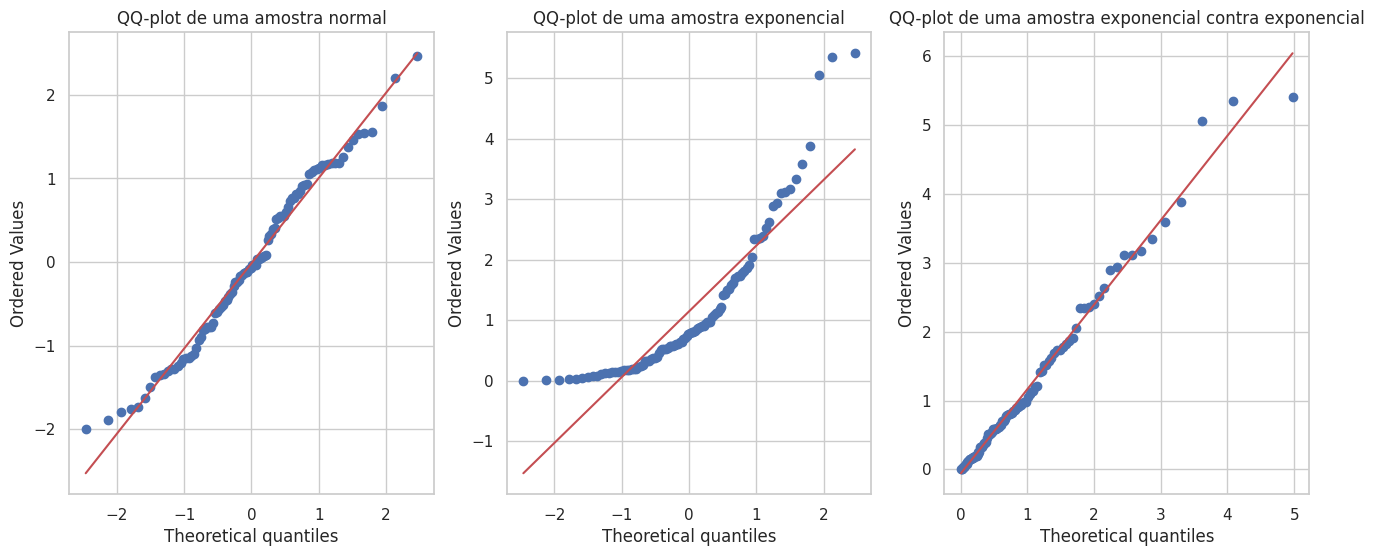

In [7]:
# QQ-plot
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np


# eixo y: valores ordenados da amostra em d

fig, ax = plt.subplots(1,3, figsize=(16,6))
norm_sample = np.random.normal(loc=0, scale=1, size=100)
stats.probplot(norm_sample, dist="norm", plot=ax[0])
ax[0].set_title("QQ-plot de uma amostra normal")

# outra amostra de outra distribuição
exp_sample = np.random.exponential(scale=1, size=100)
stats.probplot(exp_sample, dist="norm", plot=ax[1])
ax[1].set_title("QQ-plot de uma amostra exponencial")


stats.probplot(exp_sample, dist="expon", plot=ax[2])
ax[2].set_title("QQ-plot de uma amostra exponencial contra exponencial")

plt.show()

## **Distribuições de cauda pesada e cauda longa**

### **Cauda pesada**

Cauda pesada/gorda ("heavy-tailed") é o termo mais geral: refere-se a distribuições cujas caudas não são exponencialmente limitadas, ou seja, têm caudas mais pesadas que a distribuição exponencial. Em termos simples, "cauda pesada" significa que a **distribuição decai mais devagar que uma exponencial, tornando eventos extremos mais prováveis**. Numa distribuição Normal (ou exponencial), a probabilidade de um evento extremo cai drasticamente conforme você se afasta da média/centro. Numa cauda pesada, essa probabilidade cai muito mais devagar, os valores extremos ficam "mais bem distribuídos" ao redor, em vez de desaparecerem rápido.

**Exemplo:** A distribuição de riqueza. Se o Bill Gates entra em um bar, a "média" de riqueza do bar vai para bilhões, o outlier "pesa" tanto que a média perde o sentido como resumo dos dados.

### **Cauda longa**

Cauda longa (long tail) descreve quando existe uma grande quantidade de eventos/itens de baixa frequência individual, mas que, somados, representam uma parcela significativa do total. É aquela curva que desce e "anda" para a direita por muito tempo, sem encostar no zero.

**Exemplo**: o inventário da Amazon. Existem poucos best-sellers (a "cabeça" da curva), mas milhões de livros que vendem apenas 1 cópia por ano (a cauda). Somados, esses milhões de livros vendem tanto quanto, ou mais que, os best-sellers.

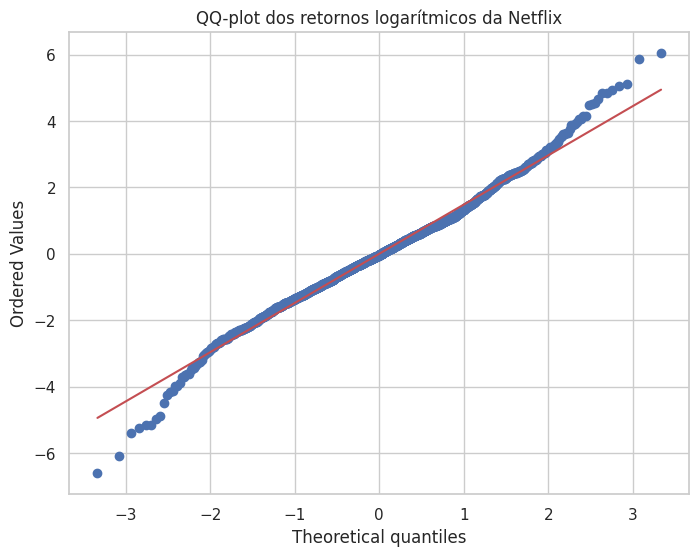

In [8]:
import pandas as pd

df = pd.read_csv("data_statistics/sp500_data.csv")

netflix = df["NFLX"]
netflix = np.diff(np.log(netflix[netflix > 0]))
fig, ax = plt.subplots(figsize=(8,6))
stats.probplot(netflix, dist="norm", plot=ax)
ax.set_title("QQ-plot dos retornos logarítmicos da Netflix")
plt.show()

## **Distribuicao T-student**

A distribuicao t-student é uma distribuicao com formato normal (gaussiano) mas um pouco mais grossa no "sino" e com as caudas mais compridas. Como se a t-student, quanto menor o grau de liberdade (tamanho da amostra) mais as curva fica gorda dando mais probabilidade para eventos mais longes da media.


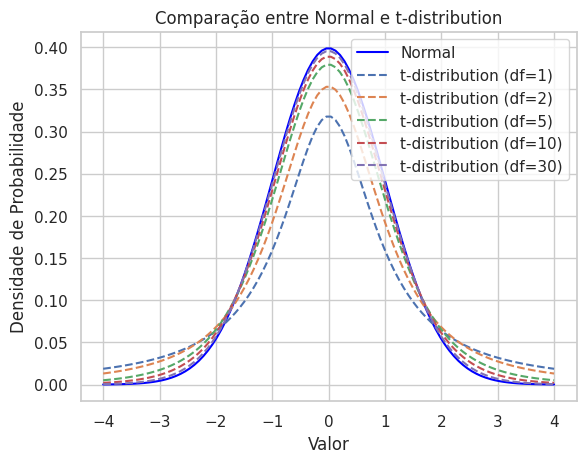

In [9]:
# Plot normal vs t-distribution para todos os valores de df 
x = np.linspace(-4, 4, 100)
normal_pdf = stats.norm.pdf(x)
plt.plot(x, normal_pdf, label="Normal", color="blue")
for df in [1, 2, 5, 10, 30]:
    t_pdf = stats.t.pdf(x, df=df)
    plt.plot(x, t_pdf, label=f"t-distribution (df={df})", linestyle="--")

plt.title("Comparação entre Normal e t-distribution")
plt.xlabel("Valor")
plt.ylabel("Densidade de Probabilidade")
plt.legend()
plt.show()

## **Distribuicao Binomial**

É a distribuicao de probabilidade de n experimentos (trials) binários em que o sucesso tem probabilidade p e o fracasso p-1. Por exemplo, jogar a moeda para cima em 10 exprimentos e em cada um temos 50% de chance de ser par ou impar. Ela pode ser util para responder questoes como: Se a probabilidade de um clique converter em venda é 0.02, qual é a probabilidade de observar 0 vendas em 200 cliques? Também pode responder coisas como probabilidade de 2 ou menos sucessos. Com n suficientimente grande e p igual aproximadamente 0.5, temos uma normal.

Probabilidade de exatamente 2: 0.0729
Probabilidade de no máximo 2: 0.9914
Probabilidade de mais de 2: 0.0086
P(2 <= X <= 5): 0.6973


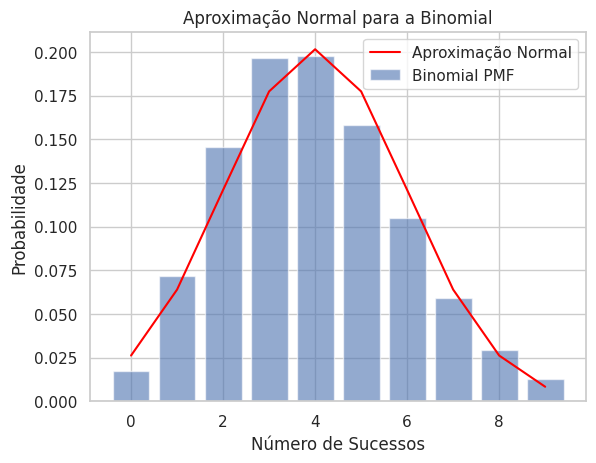

In [10]:
from scipy.stats import binom

p1 = binom.pmf(k=2, n=5, p=0.1) # 2 sucessos em 5 jogadas, com probabilidade de sucesso de 0.1 em cada jogada
p2 = binom.cdf(2, n=5, p=0.1) # maximo de 2 sucessos em 5 jogadas, com probabilidade de sucesso de 0.1 em cada jogada
p3 = binom.sf(2, n=5, p=0.1) # mais de 2 sucessos em 5 jogadas, com probabilidade de sucesso de 0.1 em cada jogada



print(f"Probabilidade de exatamente 2: {p1:.4f}")
print(f"Probabilidade de no máximo 2: {p2:.4f}")
print(f"Probabilidade de mais de 2: {p3:.4f}")


n = 200
p = 0.02
a = 2
b = 5

prob = binom.cdf(b, n, p) - binom.cdf(a-1, n, p)
print(f"P({a} <= X <= {b}): {prob:.4f}")

# aproximacao normal para a binomial
from scipy.stats import norm
n = 200
p = 0.02

mu = n * p # media da binomial
sigma = np.sqrt(n * p * (1 - p))  # desvio padrão da binomial
x = np.arange(0, 10) # gera valores de 0 a 9 para o número de sucessos

binom_pmf = binom.pmf(x, n, p) # para cada valor de x, calcula a probabilidade de obter exatamente x sucessos em n tentativas com probabilidade p usando a distribuição binomial
normal_approx = norm.pdf(x, mu, sigma) # para cada valor de x, calcula a densidade de probabilidade da distribuição normal com média mu e desvio padrão sigma usando a função de densidade de probabilidade (pdf) da distribuição normal

plt.bar(x, binom_pmf, alpha=0.6, label="Binomial PMF")
plt.plot(x, normal_approx, label="Aproximação Normal", color="red")
plt.title("Aproximação Normal para a Binomial")
plt.xlabel("Número de Sucessos")
plt.ylabel("Probabilidade")
plt.legend()
plt.show()

## **Distribuição Qui-quadrado**

Enquanto a distribuição Normal ou t-Student focam em médias de valores contínuos, a distribuição qui-quadrado é focada em contagens e categorias (frequências). Ela calcula a diferença entre a frequência esperada e a observada, gerando o valor do qui-quadrado sob a hipótese nula:

$$
\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}
$$

Onde:
- $O_i$: frequência **observada** na categoria/célula *i*
- $E_i$: frequência **esperada** na categoria/célula *i* (sob a hipótese nula)

Para cada categoria, calcula-se a diferença entre observado e esperado, eleva-se ao quadrado (para eliminar sinais negativos e penalizar desvios maiores) e divide-se pelo esperado (para normalizar, um desvio de 10 importa mais quando o esperado é 5 do que quando é 500). Depois soma-se tudo.

Essa estatística serve para ver se um conjunto de dados "se encaixa" em uma distribuição, o **teste de aderência (goodness-of-fit)**: Imagine que você lança um dado 60 vezes. Você espera que cada número caia 10 vezes ($E_i = 10$ para cada face). Se o número "6" cair 30 vezes ($O = 30$), o Qui-Quadrado vai detectar que esses dados não "se encaixam" na distribuição de um dado honesto. Ela também serve para testar **associação/independência entre duas variáveis categóricas**, nesse caso, a hipótese nula é que as variáveis são independentes, e a frequência esperada de cada célula é calculada como $E_{ij} = \frac{(\text{total da linha}) \times (\text{total da coluna})}{\text{total geral}}$. Enquanto um teste A/B comum (t-test) compara duas médias, o Qui-Quadrado é excelente para comparar múltiplos grupos e categorias ao mesmo tempo.

### **Graus de liberdade**

O formato da curva muda dependendo dos graus de liberdade (GL), que dependem de **quantas categorias** você está comparando, mas a fórmula muda conforme o tipo de teste:

- **Teste de aderência** (uma variável, contra uma distribuição teórica): $GL = k - 1$, onde *k* é o número de categorias. No exemplo do dado, $GL = 6 - 1 = 5$.
- **Teste de independência** (duas variáveis categóricas, tabela de contingência): $GL = (linhas - 1) \times (colunas - 1)$.

### **Intuição da densidade**

Quanto mais classes/categorias temos (mais graus de liberdade), maior a probabilidade do erro total ser mais alto, e mais essa variação se distribui, já que há mais termos sendo somados. Por isso que o pico da curva se desloca para direita conforme mais colunas temos.

Estatístico Qui-Quadrado: 4.6440
P-valor: 0.0981
Graus de Liberdade: 2


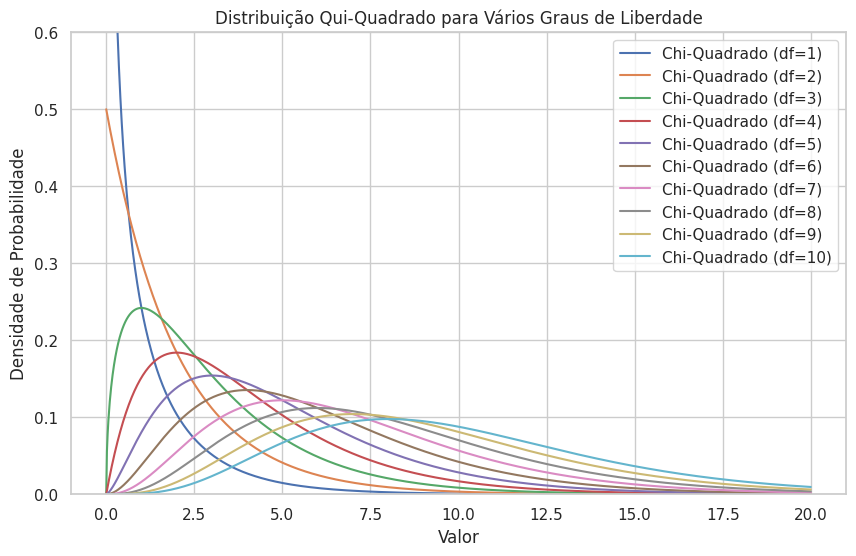

In [11]:
# Dados Observados (Tabela de Contingência)
# Linhas: Versão A, Versão B, Versão C
# Colunas: Clicou, Não Clicou
observado = np.array([
    [100, 900],  # Versão A (10% de conversão)
    [130, 870],  # Versão B (13% de conversão)
    [110, 890]   # Versão C (11% de conversão)
])

# Teste Qui-Quadrado
# chi2: Esse número é a "distância total" somada de todas as versões em relação ao que seria esperado
# p: O p-valor (a área da cauda à direita do chi2)
# dof: Graus de liberdade ( (3 linhas - 1) * (2 colunas - 1) = 2 )
# esperado: A tabela que seria real se não houvesse diferença entre as cores
chi2, p, dof, esperado = stats.chi2_contingency(observado)

print(f"Estatístico Qui-Quadrado: {chi2:.4f}")
print(f"P-valor: {p:.4f}")
print(f"Graus de Liberdade: {dof}")


# plot de curva de chi2 para varios graus de liberdade
x = np.linspace(0, 20, 1000) # 1000 pontos entre 0 e 20 para o eixo x, que representa os valores da estatística qui-quadrado (amostra de valores de chi2)
plt.figure(figsize=(10, 6))

for df in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    chi2_pdf = stats.chi2.pdf(x, df) # para cada valor de df, calcula a densidade de probabilidade da distribuição qui-quadrado usando a função de densidade de probabilidade (pdf) da distribuição qui-quadrado, e plota a curva correspondente no gráfico
    plt.plot(x, chi2_pdf, label=f"Chi-Quadrado (df={df})")

plt.ylim(0, 0.6) 

plt.title("Distribuição Qui-Quadrado para Vários Graus de Liberdade")
plt.xlabel("Valor")
plt.ylabel("Densidade de Probabilidade")
plt.legend()
plt.show()

## **F-Distribution**

É uma distribuição útil para testar vários tratamentos em múltiplos grupos (por exemplo, diferentes fertilizantes em diferentes blocos de terra). Isso é semelhante ao teste A/B/C mostrado anteriormente, mas dessa vez lidando com variáveis contínuas em vez de contagens. Se o Qui-Quadrado é para contar coisas, o F é para medir coisas.

Em poucas palavras, **F é a razão entre a variabilidade entre grupos e a variabilidade dentro dos grupos**:

$$
F = \frac{\text{MSB (variação entre grupos)}}{\text{MSW (variação dentro dos grupos)}}
$$

$$
F = \frac{\sum n_i (\bar{x}_i - \bar{x}_{geral})^2 \,/\, (k-1)}{\sum (n_i - 1)s_i^2 \,/\, (N-k)}
$$

Onde $k$ é o número de grupos e $N$ o total de observações. **F varia de 0 a infinito** (nunca é negativo, pois é razão de duas variâncias, que são sempre ≥ 0). Sob a hipótese nula, o valor esperado de F fica próximo de 1.

Hipótese nula: as médias de todos os grupos são iguais.

Imagine que você está testando 3 tipos de fertilizantes (A, B e C) em várias plantas:

- **Variabilidade ENTRE grupos**: é a diferença entre as médias de produção de cada fertilizante (o quanto as médias "pulam" de uma para a outra).
- **Variabilidade DENTRO dos grupos** (residual): é a variação natural entre plantas que usaram o mesmo fertilizante (o "ruído" ou erro natural dentro dos grupos).

### **O que o valor de F nos diz?**

- **F próximo de 1**: a variação entre os grupos é próxima da variação natural. Conclusão: os fertilizantes são todos parecidos, o que você vê é só ruído.
- **F muito maior que 1**: a diferença entre as médias dos fertilizantes é muito maior do que o ruído natural das plantas. Conclusão: pelo menos um fertilizante faz diferença real!

### **Intuição da densidade**

**Quanto mais grupos você compara** (Grau de Liberdade do Numerador, $k-1$, ex: testar 10 fertilizantes em vez de apenas 2):
- Mais "chances" de que algum grupo se afaste da média global só por acaso, assim como no Qui-Quadrado, mais categorias comparadas aumentam as oportunidades de desvio por puro azar.
- A forma da curva muda de formato: com poucos graus de liberdade no numerador (ex: 1), a curva é bem assimétrica, quase em "J"; conforme o numerador cresce, ela ganha um pico mais definido à direita do zero.

**Quanto mais plantas você mede dentro de cada grupo** (aumentando o tamanho da amostra → Grau de Liberdade do Denominador, $N-k$):
- O "ruído" fica mais preciso, você tem muito mais certeza de qual é a variação natural do seu sistema.
- A curva fica mais "comportada": com muitos dados, a distribuição F fica mais estreita e concentrada, e o valor esperado por acaso se estabiliza fortemente ao redor de 1.
- Conforme *ambos* os graus de liberdade (numerador e denominador) crescem, a distribuição F se aproxima de uma Normal.

Estatística F: 4.8862
P-valor: 0.0154


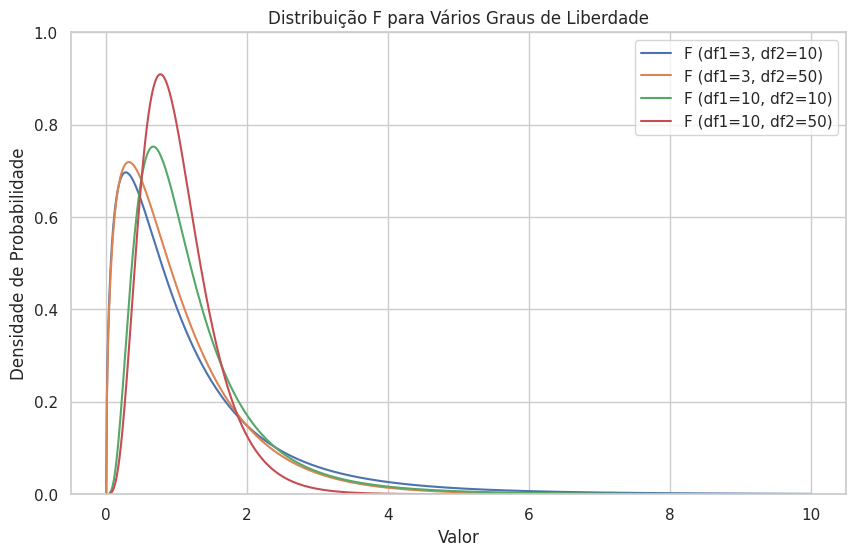

In [12]:

# peso da colheita (em gramas) para cada grupo
np.random.seed(42)
fert_A = np.random.normal(50, 5, 10)  # Média 50g
fert_B = np.random.normal(60, 5, 10)  # Média 60g (O melhor!)
fert_C = np.random.normal(52, 5, 10)  # Média 52g

# f_stat: A razão entre a variância entre grupos e dentro dos grupos
# p_val: A probabilidade de esse F acontecer por acaso
f_stat, p_val = stats.f_oneway(fert_A, fert_B, fert_C)

print(f"Estatística F: {f_stat:.4f}")
print(f"P-valor: {p_val:.4f}")

# plot de curva de F para varios graus de liberdade
x = np.linspace(0, 10, 1000) # 1000 pontos entre 0 e 10 para o eixo x, que representa os valores da estatística F (amostra de valores de F)
plt.figure(figsize=(10, 6))

for df1 in [3, 10]: # graus de liberdade do numerador (entre grupos)
    for df2 in [10, 50]: # graus de liberdade do denominador (dentro dos grupos)
        f_pdf = stats.f.pdf(x, df1, df2) # para cada combinação de df1 e df2, calcula a densidade de probabilidade da distribuição F usando a função de densidade de probabilidade (pdf) da distribuição F, e plota a curva correspondente no gráfico
        plt.plot(x, f_pdf, label=f"F (df1={df1}, df2={df2})")

plt.ylim(0, 1)
plt.title("Distribuição F para Vários Graus de Liberdade")
plt.xlabel("Valor")
plt.ylabel("Densidade de Probabilidade")
plt.legend()
plt.show()


## **Poison, Exponencial e Weibull**

- **Poisson:**

    Modela probabilidade de k eventos em um intervalo de tempo ou espaco baseado em uma estimativa lambda que é a media de acontecimentos por intervalo. Util para responder perguntas como: 

    - "Um servidor recebe, em média, 5 solicitações de acesso por minuto. Qual a probabilidade de o servidor receber exatamente 8 solicitações no próximo minuto?"
    - "Em uma linha de produção de tecidos, ocorrem em média 2 defeitos a cada 100 metros. Qual a chance de encontrarmos um rolo de 100 metros sem nenhum defeito?"
    - "Uma loja de conveniência recebe 12 clientes por hora durante a madrugada. Qual a probabilidade de chegarem mais de 20 clientes em uma hora específica?"

    $$
    P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}
    $$

    Uma limitacao aqui é que assume que a media desses eventos é fixa durante todo intervalo de tempo e isso nao necessáriamente é verdade. Uma solucao para isso seria dividir esse tempo em varios processos de poisson, ou seja, se em um dia a media durante o dia é x e a durante a noite é x2, ao inves de fazer um unico processo dividimos o dia em 2 processos de poisson.

- **Exponencial:**

    Modela probabilidade do tempo x até ocorrencia do proximo evento em um processo baseado em uma estimativa lambda que é a media de tempo. Util para responder perguntas como: 

    - "O tempo de vida de uma lâmpada de LED segue uma distribuição exponencial com média de 8.000 horas. Qual a probabilidade de uma lâmpada queimar antes de completar 1.000 horas de uso?"
    - "O tempo entre a chegada de navios em um porto é exponencial com média de 12 horas. Se um navio acabou de atracar, qual a probabilidade de o próximo navio chegar apenas daqui a 24 horas ou mais?"
    - "O intervalo entre tentativas de ataques de força bruta em um firewall segue uma distribuição exponencial com média de 10 segundos. Qual a probabilidade de ocorrer um novo ataque em menos de 2 segundos após o último?"

    $$
    f(x) = \lambda e^{-\lambda x}, \quad x \ge 0
    $$

- **Problema de estimacao da media:**

    Existem eventos muito raros e portanto poucos dados sobre eles (falha de motor de avioes). Entao temos poucos casos para estimar o tempo entre ocorrencias... poreme existem alguns chutes: Se um evento nao acontece a muuuito anos entao podemos ter certeza que a media de ocorrencia é maior que 1, pode ser feitos simulacoes ou calculos hipoteticos. Se existe dados mas sao poucos podemos usar o chi-square test para testar varias estimativas e ver qual casa melhor com os dados que temos.

- **Weibull:**

    Existem casos em que a media de eventos por tempo nao é fixa, ou seja, ela aumenta ou reduz com o tempo. Weibull é uma extensao da exponencial que adiciona um parametro *B(ou k)* em que se B>1 a probabilidade do evento aumenta com o tempo e se B<1 a probabilidade reduz com o tempo e um parametro n que define uma escala temporal daquele evento (vida caracteristica, ou tempo de vida comum). Modela o tempo de vida ou o tempo até a falha de um objeto ou sistema. O grande diferencial dela é que ela consegue descrever se um produto falha mais no começo (defeito de fábrica), de forma constante (acidente) ou no final (desgaste).

    - Se muitos aparelhos falham nas primeiras 48 horas devido a problemas de solda, a curva de Weibull ajuda a empresa a decidir por quanto tempo o produto deve ser testado na fábrica antes de ser enviado às lojas (o chamado burn-in)
    - Modelando o tempo até o surgimento de rachaduras com B>1 (geralmente entre 2 e 3), os engenheiros conseguem prever exatamente em qual ano a probabilidade de falha será alta demais, permitindo trocar a pá antes que ela quebre e destrua a turbina
    - Em testes de novos medicamentos contra o câncer, os pesquisadores usam a Weibull para descrever a probabilidade de um paciente permanecer livre da doença ao longo dos meses. Se a droga funciona bem, o parâmetro de escala da distribuição "empurra" a curva de sobrevivência para a direita, indicando uma vida mais longa.

    $$
    f(x) = 
    \frac{k}{\lambda}
    \left( \frac{x}{\lambda} \right)^{k-1}
    e^{-(x/\lambda)^k},
    \quad x \ge 0
    $$

In [13]:
from scipy.stats import poisson, expon

# Poisson 

# simulando o número de eventos (ex: chamadas em um call center) em um intervalo de tempo, onde a média é 5 eventos por hora
poisson_sample = poisson.rvs(5, size=10) # cada valor representa o número de chamadas em uma hora, e a média desses valores deve ser aproximadamente 5, refletindo a média da distribuição Poisson que estamos simulando.
print("Alguns valores simulados da distribuição Poisson (média = 5):")
print(poisson_sample)

# Exponencial

# simulando o tempo entre eventos (ex: tempo entre chamadas em um call center) onde a média é 1 hora
expon_sample = expon.rvs(scale=1, size=10) # representa o tempo entre chamadas, e a média desses valores deve ser aproximadamente 1 hora, refletindo a média da distribuição Exponencial que estamos simulando. O parâmetro scale=1 indica que a média da distribuição é 1, ou seja, o tempo médio entre eventos é de 1 hora.
print("\nAlguns valores simulados da distribuição Exponencial (média = 1 hora):")
print(expon_sample)

# Weibull

# simulando o tempo até a falha de um componente, onde a forma é 1.5 e a escala é 1000 horas
weibull_sample = stats.weibull_min.rvs(1.5, scale=1000, size=10) # cada valor representa o tempo até a falha de um componente, e a média desses valores deve ser aproximadamente 1000 horas, refletindo a escala da distribuição Weibull que estamos simulando. O parâmetro c=1.5 indica a forma da distribuição, onde valores menores que 1 indicam uma taxa de falha decrescente ao longo do tempo, valores iguais a 1 indicam uma taxa de falha constante, e valores maiores que 1 indicam uma taxa de falha crescente ao longo do tempo.
print("\nAlguns valores simulados da distribuição Weibull (forma = 1.5, escala = 1000 horas):")
print(weibull_sample)





Alguns valores simulados da distribuição Poisson (média = 5):
[4 6 7 2 5 5 6 4 6 6]

Alguns valores simulados da distribuição Exponencial (média = 1 hora):
[0.11416744 0.03193368 1.01172955 0.37739671 0.71043718 2.38126553
 0.28673882 0.52828197 1.40874915 0.25980516]

Alguns valores simulados da distribuição Weibull (forma = 1.5, escala = 1000 horas):
[ 185.8248577   489.18089939  313.82895643 1917.36254968 1396.83436992
 1002.32810585 1614.54615775 1383.87674039  349.36041495 1707.29602966]
